# MLP -- PM2.5

Shortest, noisiest of the 4 target series -- worth watching a small neural
net on. Light hyperparameters by default (fast, actually runs). The heavy
grid-search cell below stays commented out -- manual exploration only,
never runs in CI or Airflow.

In [1]:
import matplotlib.pyplot as plt

from src.ml.evaluate import last_fold_predictions, walk_forward_evaluate
from src.ml.models.sklearn_models import MLPModel
from src.ml.promote import _variable_config

In [2]:
variable = "PM2.5"
ano = 2024
air_path = "data/silver/aire/all.parquet"
traffic_path = "data/silver/trafico/all.parquet"
runs_dir = "data/gold/ml_runs"

In [3]:
df, target_col, feature_cols, partition_col = _variable_config(
    variable, air_path, traffic_path
)
df.shape

(5219, 10)

## EDA -- distribution and time series of the target

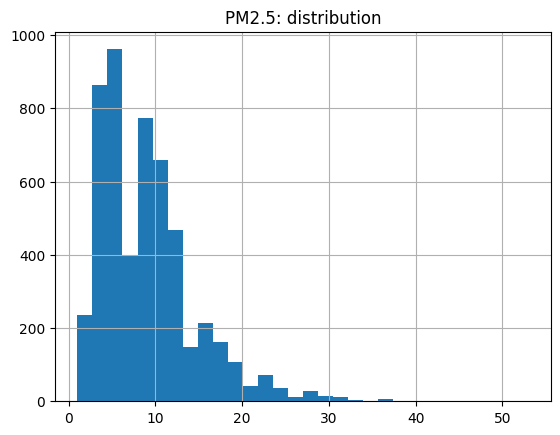

In [4]:
df[target_col].hist(bins=30)
plt.title(f"{variable}: distribution")
plt.show()

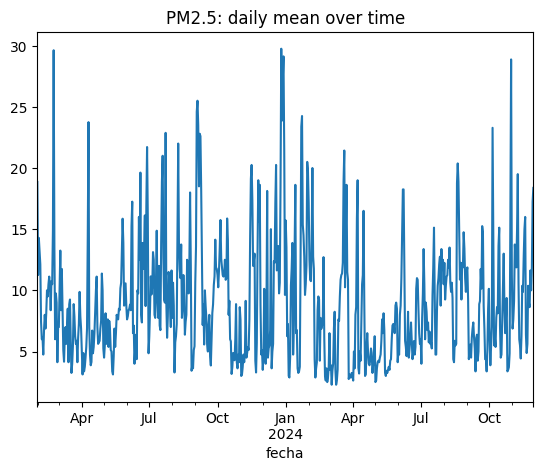

In [5]:
df.groupby("fecha")[target_col].mean().plot()
plt.title(f"{variable}: daily mean over time")
plt.show()

## Light hyperparameters (default, executed)

In [6]:
model = MLPModel(hidden_layer_sizes=(16,), max_iter=300)

## Heavy grid search -- commented out, uncomment to run (slow)

In [7]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.neural_network import MLPRegressor
#
# param_grid = {
#     "hidden_layer_sizes": [(16,), (32,), (32, 16)],
#     "alpha": [1e-4, 1e-3, 1e-2],
# }
# search = GridSearchCV(
#     MLPRegressor(random_state=42, max_iter=1000),
#     param_grid,
#     scoring="neg_root_mean_squared_error",
#     cv=3,
#     n_jobs=-1,
# )
# search.fit(df[feature_cols], df[target_col])
# print(search.best_params_, -search.best_score_)

## Walk-forward evaluation + held-out real vs. predicted

In [8]:
comparison = walk_forward_evaluate([model], df, target_col, feature_cols)
comparison

C:\Users\josab\Documents\app_claude\github_repo\MadridSmartData\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


,model,mae,rmse,mape
0,mlp,2.959886,4.116712,0.448856


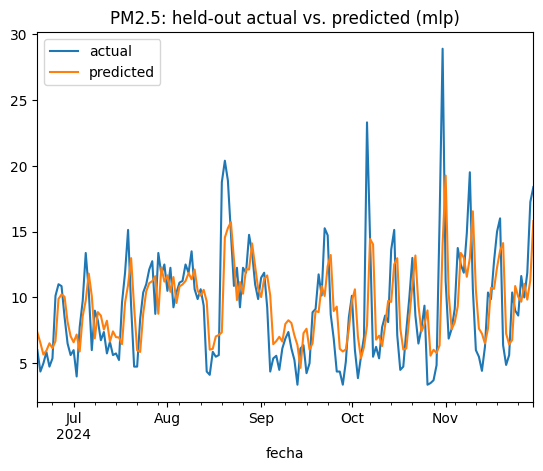

In [9]:
holdout = last_fold_predictions(
    model.__class__(), df, target_col, feature_cols, partition_col
)
holdout.groupby("fecha")[["actual", "predicted"]].mean().plot()
plt.title(f"{variable}: held-out actual vs. predicted ({model.name})")
plt.show()

MLP has no feature-importance equivalent -- skipping that plot for this
model.

## Write this model's run -- never touches `gold/ml_<variable>_<ano>.*`
directly, only `promote.promote_winner` does that.

In [10]:
from pathlib import Path  # noqa: E402

Path(runs_dir).mkdir(parents=True, exist_ok=True)
out = Path(runs_dir) / f"{variable}_{model.name}_{ano}.parquet"
comparison.to_parquet(out)
out

WindowsPath('data/gold/ml_runs/PM2.5_mlp_2024.parquet')